# HillClimbing


Created on Thu Nov 27 15:59:22 2025

@author: gustaaragao

In [2]:
from src.problems.Sphere import Sphere
from src.MOEAs.HillClimbing import HillClimbing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Parameters
D = 30
max_evaluations = 50_000

p_values = [0.125, 0.25, 0.5, 1.0]
r_values = [0.5, 1.0, 5.0, 10.0, 20.0, 50.0]

In [4]:
def simulate(p, r):
   # Create the problem
    problem = Sphere(numberOfDecisionVariables=D)
    
    # Create the algorithm
    algorithm = HillClimbing(
        problem=problem,
        maxEvaluations=max_evaluations,
        probability=p,
        range_noise=r
    )
    
    # Execute the algorithm
    best = algorithm.execute()
    
    result = {
        'p': p,
        'r': r,
        'best_fitness': best.objectives[0],
        'evaluations': algorithm.evaluations
    }
    
    return result


In [9]:
rows = []

# Simulate Hill-Climbing
for p in p_values:
    for r in r_values:
        rows.append(simulate(p, r))

df = pd.DataFrame(rows)
df

,p,r,best_fitness,evaluations
0,0.125,0.5,0.000579,50000
1,0.125,1.0,0.002810,50000
2,0.125,5.0,0.084480,50000
3,0.125,10.0,0.325815,50000
4,0.125,20.0,1.161779,50000
5,0.125,50.0,2.580520,50000
6,0.250,0.5,0.050619,50000
7,0.250,1.0,0.182215,50000
8,0.250,5.0,2.894990,50000
9,0.250,10.0,6.479623,50000


# Graphs of the Function from the “Sphere” Problem

In [10]:
# Create a 2D grid for visualization
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Calculate Sphere function values (for 2D: f(x,y) = x² + y²)
Z = X**2 + Y**2

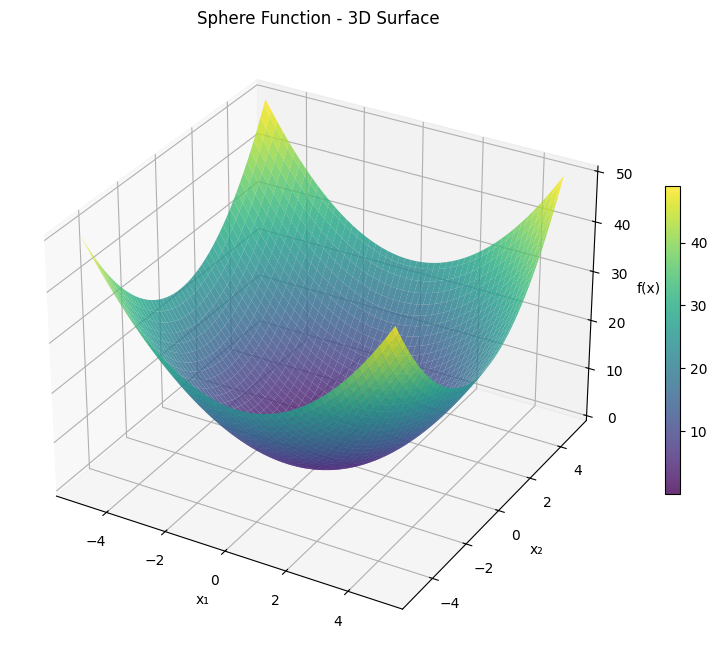

In [11]:
# 3D Surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('f(x)')
ax.set_title('Sphere Function - 3D Surface')
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.show()

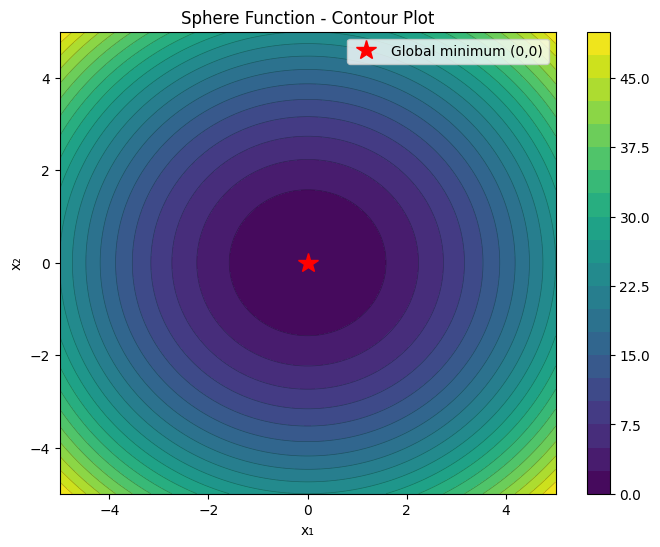

In [12]:
# Contour plot
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
ax.contour(X, Y, Z, levels=20, colors='black', alpha=0.3, linewidths=0.5)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Sphere Function - Contour Plot')
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum (0,0)')
ax.legend()
fig.colorbar(contour, ax=ax)
plt.show()

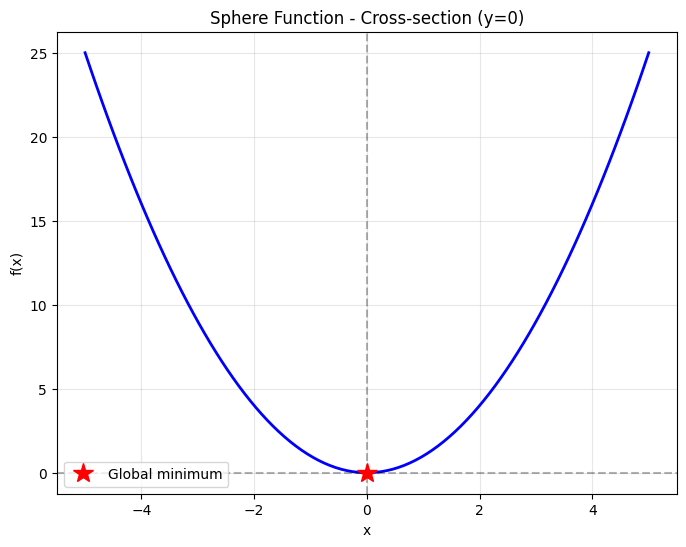

In [13]:
# Cross-section (1D slice at y=0)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, x**2, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Sphere Function - Cross-section (y=0)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum')
ax.legend()
plt.show()